# Import the Packages and checking GPU Activation

### In this model training we will feed the features to the Conv2D block from SE block

In [36]:
## Performance Not satisfactory

In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


I0000 00:00:1778629833.610310    5498 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


# Import pre-processing tools and ML framework

In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)

# Define the size of Image, Batch Size for image processing

In [3]:
IMG_SIZE   = 256
BATCH_SIZE = 4        
EPOCHS     = 100

# Model Save path and data path

In [4]:
DATA_PATH  = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/Kvasir-SEG'
MODEL_SAVE = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/best_unet_v_12_05_26.keras'

# Image Augmentation 

In [5]:
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask

# Image Preprocessing

In [6]:
def process_path(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE],
                           method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return img, mask

# Fetch Image Dataset


In [7]:
def get_dataset(x, y, batch=BATCH_SIZE, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(buffer_size=len(x), reshuffle_each_iteration=True)
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Loss and metrics

In [8]:
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

# Dice Loss, BCE Dice Loss and IoU Metric

In [18]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)
    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true_f, y_pred_f)
    )
    return bce + dice_loss(y_true_f, y_pred_f)

def iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1.0) / (union + 1.0)

# Squeeze-and-Excitation Block

In [23]:
def se_block(input_tensor, ratio=8):
    """Squeeze-and-Excitation Block"""
    channels = input_tensor.shape[-1]
    
    # Squeeze: Global Information Capture
    # (Batch, H, W, C) -> (Batch, 1, 1, C)
    squeeze = layers.GlobalAveragePooling2D()(input_tensor)
    
    # Excitation: Learning channel-wise weights
    excitation = layers.Dense(channels // ratio, activation='relu', use_bias=False)(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid', use_bias=False)(excitation)
    
    # Reshape for multiplication
    excitation = layers.Reshape((1, 1, channels))(excitation)
    
    # Scale: Multiply original input by learned weights
    return layers.multiply([input_tensor, excitation])

# Conv2D Block

In [27]:
def conv_block(x, filters, dropout_rate=0.0):
    """SE Block -> Conv -> BN -> ReLU x 2"""
    # First Convolution Block
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = se_block(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
        
    # Second Convolution
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    return x

# Build Unet-SE-Conv Modle

In [30]:
def build_unet_se_lite(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # ── Encoder (Downsampling) ──────────────────
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = conv_block(p2, 128, dropout_rate=0.1)
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = conv_block(p3, 256, dropout_rate=0.2)
    p4 = layers.MaxPooling2D(2)(c4)

    # ── Bottleneck ──────────────────────────────
    b = conv_block(p4, 512, dropout_rate=0.3)

    # ── Decoder (Upsampling) ────────────────────
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(b)
    u4 = layers.concatenate([u4, c4])
    c5 = conv_block(u4, 256, dropout_rate=0.2)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c5)
    u3 = layers.concatenate([u3, c3])
    c6 = conv_block(u3, 128, dropout_rate=0.1)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c6)
    u2 = layers.concatenate([u2, c2])
    c7 = conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c7)
    u1 = layers.concatenate([u1, c1])
    c8 = conv_block(u1, 32)

    # Output Layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32')(c8)

    return models.Model(inputs, outputs, name='SE-Conv2D-Unet-v1.0.0')



In [31]:
model = build_unet_se_lite()
model.summary()

Model: "SE-Conv2D-Unet-v1.0.0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_19[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 4)         │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │        128 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 256, 256,  │          0 │ conv2d_19[0][0],  │
│ (Multiply)          │ 32)               │            │ reshape_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ multiply_9[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,216 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_21[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8)         │        512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │        512 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 1, 1, 64)  │          0 │ dense_21[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,877,985 (30.05 MB)

 Trainable params: 7,872,097 (30.03 MB)

 Non-trainable params: 5,888 (23.00 KB)

Total samples: 1000
Train: 800  |  Val: 200


Model: "SE-Conv2D-Unet-v1.0.0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_38[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 4)         │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 32)        │        128 │ dense_36[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_18          │ (None, 1, 1, 32)  │          0 │ dense_37[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_18         │ (None, 256, 256,  │          0 │ conv2d_38[0][0],  │
│ (Multiply)          │ 32)               │            │ reshape_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ multiply_18[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      9,216 │ activation_36[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ activation_37[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 128, 128,  │     18,432 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_40[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 8)         │        512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 64)        │        512 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_19          │ (None, 1, 1, 64)  │          0 │ dense_39[0][0]    │
│ (Reshape)           │                   │            │                 

 Total params: 7,877,985 (30.05 MB)

 Trainable params: 7,872,097 (30.03 MB)

 Non-trainable params: 5,888 (23.00 KB)


========== Training Started ==========
Epoch 1/100


I0000 00:00:1778631965.693839   24137 service.cc:153] XLA service 0x74ac340637d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778631965.694134   24137 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778631966.154166   24137 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778631969.047336   24137 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778631969.624697   24137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22216__.276
W0000 00:00:1778631974.363880   24137 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7458 - dice_coef: 0.3088 - iou_metric: 0.2400 - loss: 1.1693
Epoch 1: val_dice_coef improved from None to 0.19771, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/best_unet_v_12_05_26.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/best_unet_v_12_05_26.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 93s 89ms/step - accuracy: 0.7872 - dice_coef: 0.3214 - iou_metric: 0.2415 - loss: 1.0960 - val_accuracy: 0.7337 - val_dice_coef: 0.1977 - val_iou_metric: 0.1240 - val_loss: 2.7126 - learning_rate: 0.0010
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8053 - dice_coef: 0.3443 - iou_metric: 0.2548 - loss: 1.0436
Epoch 2: val_dice_coef improved from 0.19771 to 0.32019, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/best_unet_v_12_05_26.keras

Epoch 2: fin

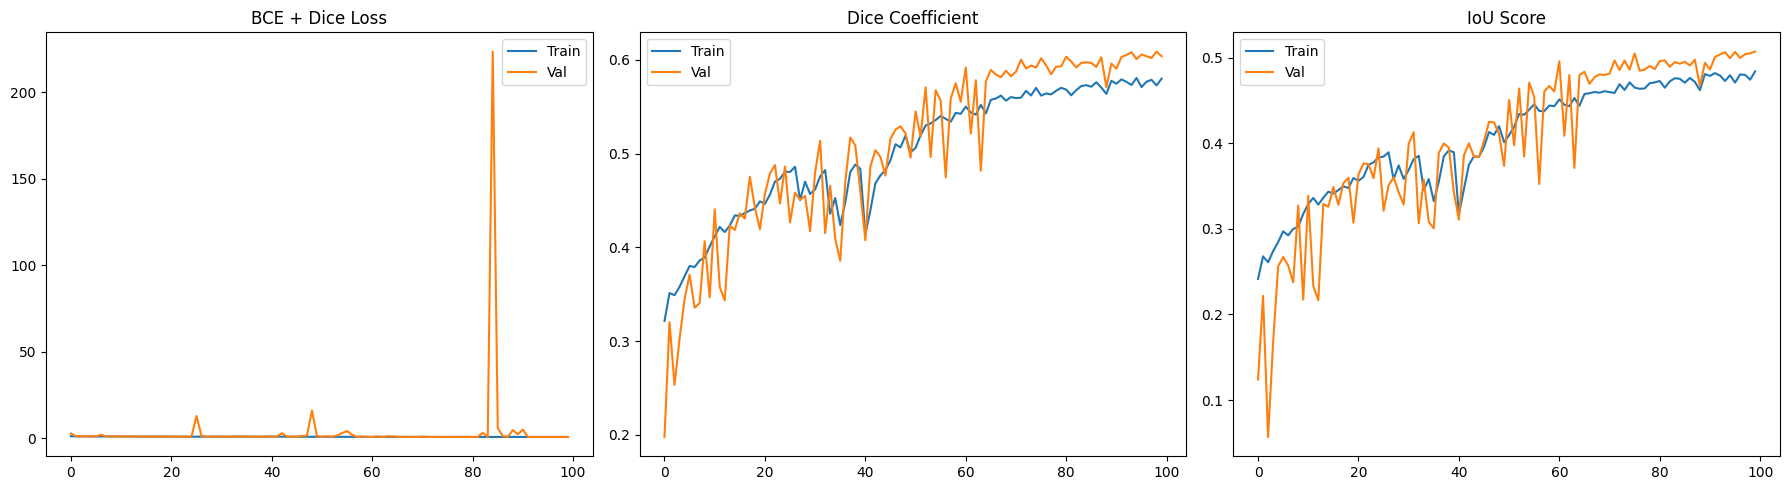

In [32]:
if __name__ == '__main__':

    images = sorted(glob.glob(os.path.join(DATA_PATH, 'images/*.jpg')))
    masks  = sorted(glob.glob(os.path.join(DATA_PATH, 'masks/*.jpg')))
    print(f"Total samples: {len(images)}")

    train_x, val_x, train_y, val_y = train_test_split(
        images, masks, test_size=0.2, random_state=42
    )
    print(f"Train: {len(train_x)}  |  Val: {len(val_x)}")

    train_ds = get_dataset(train_x, train_y, batch=BATCH_SIZE, augment_data=True)
    val_ds   = get_dataset(val_x,   val_y,   batch=BATCH_SIZE, augment_data=False)

    unet_se = build_unet_se_lite()
    unet_se.summary()

    # Mixed precision → optimizer loss scaling দরকার
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    optimizer = mixed_precision.LossScaleOptimizer(optimizer)

    unet_se.compile(
        optimizer=optimizer,
        loss=bce_dice_loss,
        metrics=[dice_coef, iou_metric, 'accuracy']
    )

    os.makedirs(os.path.dirname(MODEL_SAVE), exist_ok=True)

    callbacks = [
        ModelCheckpoint(MODEL_SAVE, monitor='val_dice_coef',
                        save_best_only=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_dice_coef', patience=20,
                      restore_best_weights=True, mode='max', verbose=1),
    ]

    print("\n========== Training Started ==========")
    history = unet_se.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    print("========== Training Complete ==========\n")

    # ── Plot ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(history.history['loss'],          label='Train')
    axes[0].plot(history.history['val_loss'],      label='Val')
    axes[0].set_title('BCE + Dice Loss'); axes[0].legend()

    axes[1].plot(history.history['dice_coef'],     label='Train')
    axes[1].plot(history.history['val_dice_coef'], label='Val')
    axes[1].set_title('Dice Coefficient'); axes[1].legend()

    axes[2].plot(history.history['iou_metric'],     label='Train')
    axes[2].plot(history.history['val_iou_metric'], label='Val')
    axes[2].set_title('IoU Score'); axes[2].legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()


# Test and Display

In [33]:
def test_and_display(model, image_path):
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    inp     = np.expand_dims(img_res / 255.0, axis=0).astype(np.float32)

    pred_mask = model.predict(inp, verbose=0)[0]
    mask_bin  = (pred_mask > 0.5).astype(np.uint8)
    mask_3d   = np.concatenate([mask_bin] * 3, axis=-1)
    extracted = (img_res * mask_3d).astype(np.uint8)

    titles = ['Original', 'Predicted Mask', 'Extracted Polyp']
    images = [img_res, pred_mask.squeeze(), extracted]
    plt.figure(figsize=(15, 5))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i], cmap='gray' if i == 1 else None)
        plt.title(titles[i], fontsize=14)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150)
    plt.show()

E0000 00:00:1778634284.352587   24137 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


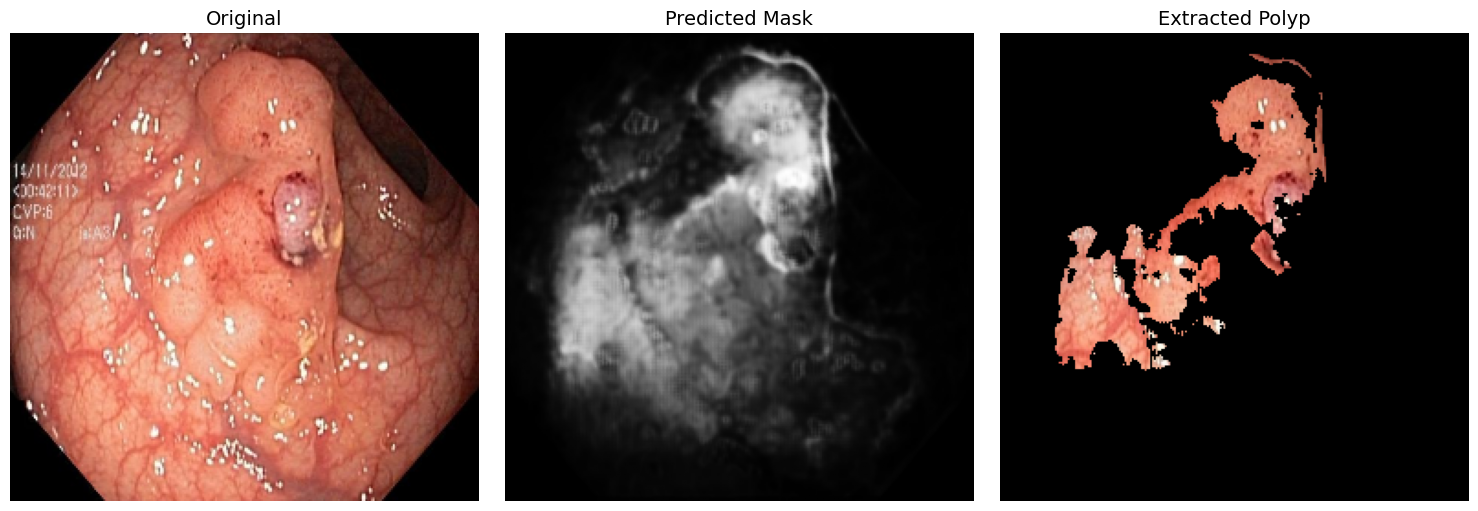

In [34]:
  if images:
        test_and_display(unet_se, images[2])

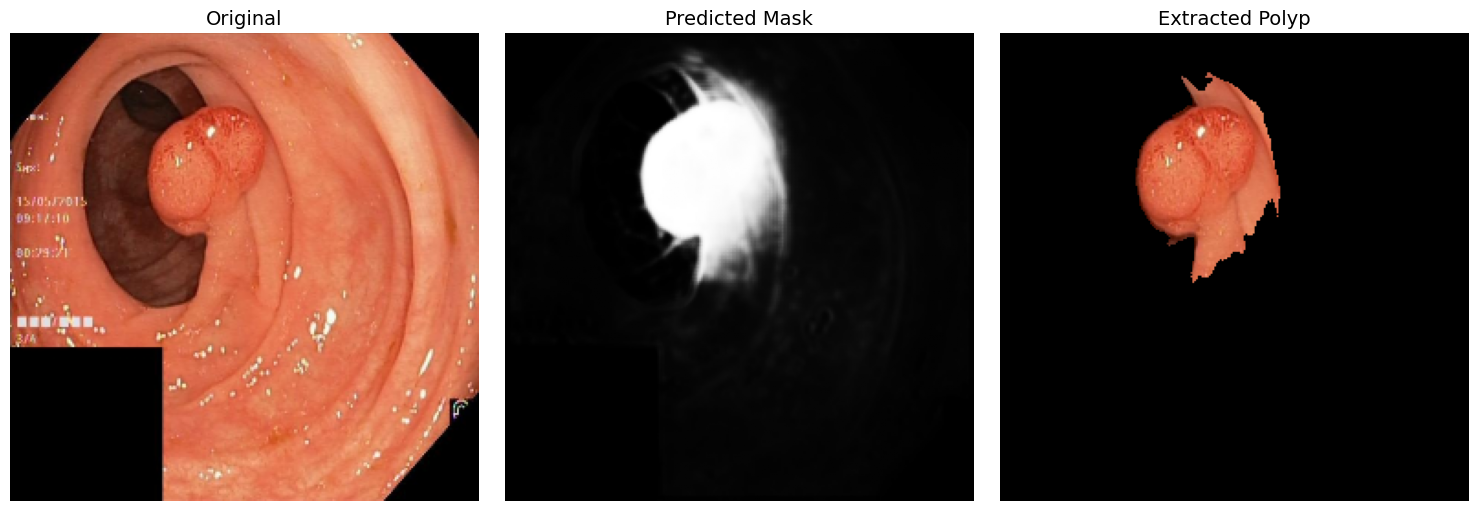

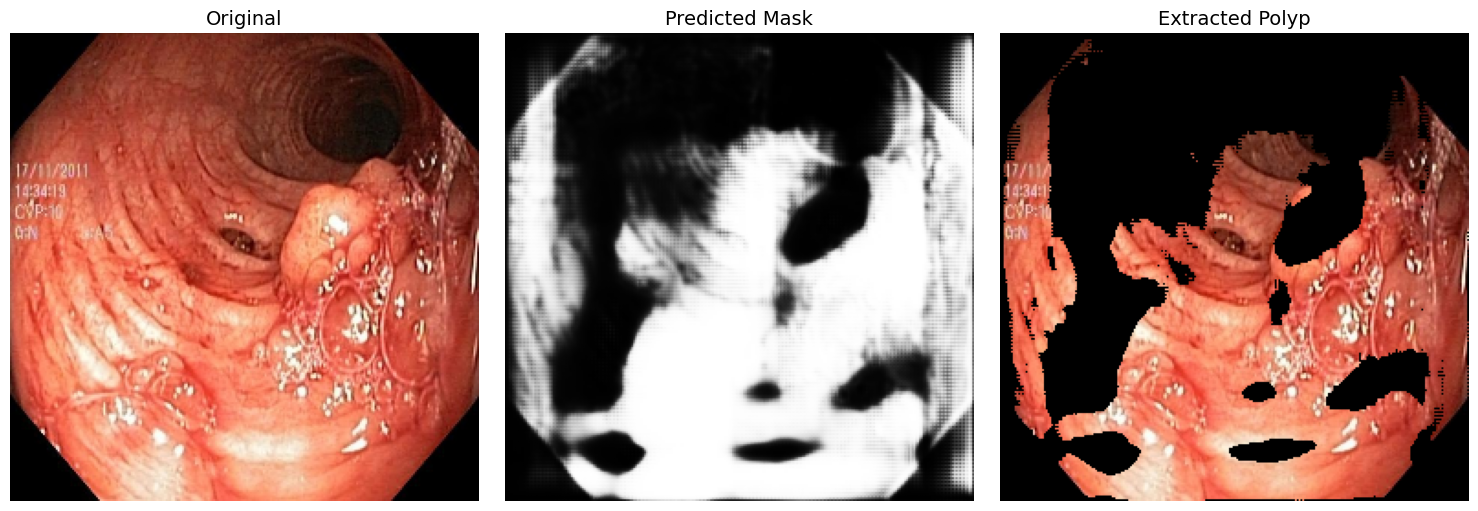

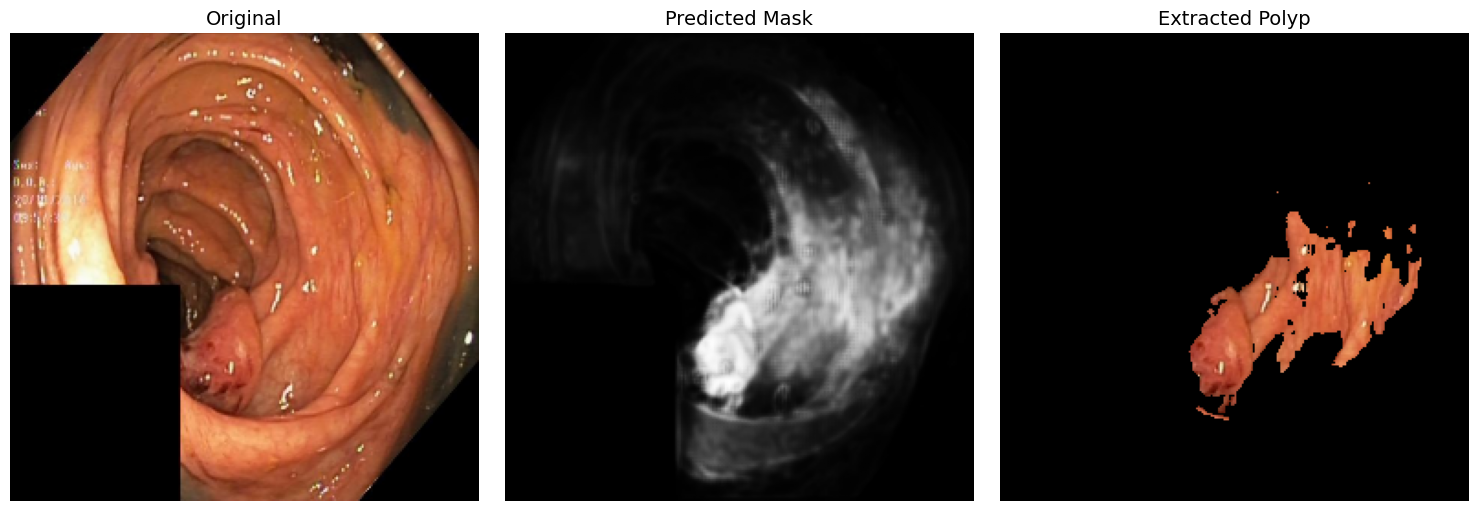

In [35]:
import random

if images:
    for _ in range(3):  # run 3 times
        i = random.randint(1, 25)  # random integer between 1 and 25
        test_and_display(unet_se, images[i])